# Projet sur les algorithmes d'optimisations

## Partie 1 - Programmation linéaire avec PuLP

### Description des variables:
- **xa_A:** Variable binaire qui indique si Alice est dans l'équipe A ou non (1 ou 0)
- **xa_B:** Variable binaire qui indique si Alice est dans l'équipe B ou non (1 ou 0)
- **xb_A:** Variable binaire qui indique si Bob est dans l'équipe A ou non (1 ou 0)
- **xb_B:** Variable binaire qui indique si Bob est dans l'équipe B ou non (1 ou 0)
- **xc_A:** Variable binaire qui indique si Clara est dans l'équipe A ou non (1 ou 0)
- **xc_B:** Variable binaire qui indique si Clara est dans l'équipe B ou non (1 ou 0)
- **xd_A:** Variable binaire qui indique si David est dans l'équipe A ou non (1 ou 0)
- **xd_B:** Variable binaire qui indique si David est dans l'équipe B ou non (1 ou 0)
- **xe_A:** Variable binaire qui indique si Emma est dans l'équipe A ou non (1 ou 0)
- **xe_B:** Variable binaire qui indique si Emma est dans l'équipe B ou non (1 ou 0)
- **xf_A:** Variable binaire qui indique si Frank est dans l'équipe A ou non (1 ou 0)
- **xf_B:** Variable binaire qui indique si Frank est dans l'équipe B ou non (1 ou 0)
- **xg_A:** Variable binaire qui indique si Grace est dans l'équipe A ou non (1 ou 0)
- **xg_B:** Variable binaire qui indique si Grace est dans l'équipe B ou non (1 ou 0)
- **xh_A:** Variable binaire qui indique si Hugo est dans l'équipe A ou non (1 ou 0)
- **xh_B:** Variable binaire qui indique si Hugo est dans l'équipe B ou non (1 ou 0)

In [130]:
from turtledemo.chaos import plot

from matplotlib import pyplot as plt
from pulp import *
from wcwidth import width

joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

# 1. Définition du problème
prob = LpProblem("Algorithme_de_programmation_linéaire", LpMaximize)

# 2. Variables de décisions
xa_A = LpVariable("xa_A", cat='Binary')
xa_B = LpVariable("xa_B", cat='Binary')
xb_A = LpVariable("xb_A", cat='Binary')
xb_B = LpVariable("xb_B", cat='Binary')
xc_A = LpVariable("xc_A", cat='Binary')
xc_B = LpVariable("xc_B", cat='Binary')
xd_A = LpVariable("xd_A", cat='Binary')
xd_B = LpVariable("xd_B", cat='Binary')
xe_A = LpVariable("xe_A", cat='Binary')
xe_B = LpVariable("xe_B", cat='Binary')
xf_A = LpVariable("xf_A", cat='Binary')
xf_B = LpVariable("xf_B", cat='Binary')
xg_A = LpVariable("xg_A", cat='Binary')
xg_B = LpVariable("xg_B", cat='Binary')
xh_A = LpVariable("xh_A", cat='Binary')
xh_B = LpVariable("xh_B", cat='Binary')    

# 3.1. Contraintes du nombre de joueurs par équipe
prob += (xa_A + xb_A + xc_A + xd_A + xe_A + xf_A + xg_A + xh_A) == 3
prob += (xa_B + xb_B + xc_B + xd_B + xe_B + xf_B + xg_B + xh_B) == 3

# 3.2. Contraintes du nombre d'équipes par joueur
prob += (xa_A + xa_B) <= 1
prob += (xb_A + xb_B) <= 1
prob += (xc_A + xc_B) <= 1
prob += (xd_A + xd_B) <= 1
prob += (xe_A + xe_B) <= 1
prob += (xf_A + xf_B) <= 1
prob += (xg_A + xg_B) <= 1
prob += (xh_A + xh_B) <= 1

# 3.3. Contraintes de poids
prob += ((joueurs[0]["poids"]*xa_A) +
         (joueurs[1]["poids"]*xb_A) +
         (joueurs[2]["poids"]*xc_A) +
         (joueurs[3]["poids"]*xd_A) +
         (joueurs[4]["poids"]*xe_A) +
         (joueurs[5]["poids"]*xf_A) +
         (joueurs[6]["poids"]*xg_A) +
         (joueurs[7]["poids"]*xh_A)) <= 250
prob += ((joueurs[0]["poids"]*xa_B) +
         (joueurs[1]["poids"]*xb_B) +
         (joueurs[2]["poids"]*xc_B) +
         (joueurs[3]["poids"]*xd_B) +
         (joueurs[4]["poids"]*xe_B) +
         (joueurs[5]["poids"]*xf_B) +
         (joueurs[6]["poids"]*xg_B) +
         (joueurs[7]["poids"]*xh_B)) <= 250

# 3.4. Contrainte de salaire
prob += ((joueurs[0]["salaire"]*(xa_A + xa_B)) +
        (joueurs[1]["salaire"]*(xb_A + xb_B)) +
        (joueurs[2]["salaire"]*(xc_A + xc_B)) +
        (joueurs[3]["salaire"]*(xd_A + xd_B)) +
        (joueurs[4]["salaire"]*(xe_A + xe_B)) +
        (joueurs[5]["salaire"]*(xf_A + xf_B)) +
        (joueurs[6]["salaire"]*(xg_A + xg_B)) +
        (joueurs[7]["salaire"]*(xh_A + xh_B))) <= 8500

# 4. Fonction objective
prob += ((joueurs[0]["score"]*(xa_A + xa_B)) +
        (joueurs[1]["score"]*(xb_A + xb_B)) +
        (joueurs[2]["score"]*(xc_A + xc_B)) +
        (joueurs[3]["score"]*(xd_A + xd_B)) +
        (joueurs[4]["score"]*(xe_A + xe_B)) +
        (joueurs[5]["score"]*(xf_A + xf_B)) +
        (joueurs[6]["score"]*(xg_A + xg_B)) +
        (joueurs[7]["score"]*(xh_A + xh_B)))

# 5. Résolution
prob.solve(PULP_CBC_CMD(msg=False))

# 6.1. Composition des équipes
print(f"Statut : {LpStatus[prob.status]}")
print()
print("\033[4mNom: \t\t Équipe A \t Équipe B\033[0m")
print(f"Alice: \t\t {xa_A.value()} \t\t {xa_B.value()}")
print(f"Bob: \t\t {xb_A.value()} \t\t {xb_B.value()}")
print(f"Clara: \t\t {xc_A.value()} \t\t {xc_B.value()}")
print(f"David: \t\t {xd_A.value()} \t\t {xd_B.value()}")
print(f"Emma: \t\t {xe_A.value()} \t\t {xe_B.value()}")
print(f"Frank: \t\t {xf_A.value()} \t\t {xf_B.value()}")
print(f"Grace: \t\t {xg_A.value()} \t\t {xg_B.value()}")
print(f"Hugo: \t\t {xh_A.value()} \t\t {xh_B.value()}\n")

# 6.2. Poids par équipe
poids_equipe_A_PuLP = ((joueurs[0]["poids"]*xa_A.value()) +
                                    (joueurs[1]["poids"]*xb_A.value()) +
                                    (joueurs[2]["poids"]*xc_A.value()) +
                                    (joueurs[3]["poids"]*xd_A.value()) +
                                    (joueurs[4]["poids"]*xe_A.value()) +
                                    (joueurs[5]["poids"]*xf_A.value()) +
                                    (joueurs[6]["poids"]*xg_A.value()) +
                                    (joueurs[7]["poids"]*xh_A.value()))
print(f"Poids de l'équipe A: {poids_equipe_A_PuLP} kg")

poids_equipe_B_PuLP = ((joueurs[0]["poids"]*xa_B.value()) +
                                     (joueurs[1]["poids"]*xb_B.value()) +
                                     (joueurs[2]["poids"]*xc_B.value()) +
                                     (joueurs[3]["poids"]*xd_B.value()) +
                                     (joueurs[4]["poids"]*xe_B.value()) +
                                     (joueurs[5]["poids"]*xf_B.value()) +
                                     (joueurs[6]["poids"]*xg_B.value()) +
                                     (joueurs[7]["poids"]*xh_B.value()))
print(f"Poids de l'équipe B: {poids_equipe_B_PuLP} kg\n")

# 6.3. Coût pour les salaires
budget_equipe_A_PuLP = ((joueurs[0]["salaire"]*xa_A.value()) +
                                        (joueurs[1]["salaire"]*xb_A.value()) +
                                        (joueurs[2]["salaire"]*xc_A.value()) +
                                        (joueurs[3]["salaire"]*xd_A.value()) +
                                        (joueurs[4]["salaire"]*xe_A.value()) +
                                        (joueurs[5]["salaire"]*xf_A.value()) +
                                        (joueurs[6]["salaire"]*xg_A.value()) +
                                        (joueurs[7]["salaire"]*xh_A.value()))
print(f"Coût pour les salaires de l'équipe A : {budget_equipe_A_PuLP}$")

budget_equipe_B_PuLP = ((joueurs[0]["salaire"]*xa_B.value()) +
                                        (joueurs[1]["salaire"]*xb_B.value()) +
                                        (joueurs[2]["salaire"]*xc_B.value()) +
                                        (joueurs[3]["salaire"]*xd_B.value()) +
                                        (joueurs[4]["salaire"]*xe_B.value()) +
                                        (joueurs[5]["salaire"]*xf_B.value()) +
                                        (joueurs[6]["salaire"]*xg_B.value()) +
                                        (joueurs[7]["salaire"]*xh_B.value()))
print(f"Coût pour les salaires de l'équipe B: {budget_equipe_B_PuLP}$")

budget_total_PuLP = ((joueurs[0]["salaire"]*xa_A.value()) +
                                        (joueurs[1]["salaire"]*xb_A.value()) +
                                        (joueurs[2]["salaire"]*xc_A.value()) +
                                        (joueurs[3]["salaire"]*xd_A.value()) +
                                        (joueurs[4]["salaire"]*xe_A.value()) +
                                        (joueurs[5]["salaire"]*xf_A.value()) +
                                        (joueurs[6]["salaire"]*xg_A.value()) +
                                        (joueurs[7]["salaire"]*xh_A.value()) +
                                        (joueurs[0]["salaire"]*xa_B.value()) +
                                        (joueurs[1]["salaire"]*xb_B.value()) +
                                        (joueurs[2]["salaire"]*xc_B.value()) +
                                        (joueurs[3]["salaire"]*xd_B.value()) +
                                        (joueurs[4]["salaire"]*xe_B.value()) +
                                        (joueurs[5]["salaire"]*xf_B.value()) +
                                        (joueurs[6]["salaire"]*xg_B.value()) +
                                        (joueurs[7]["salaire"]*xh_B.value()))
print(f"\033[1mCoût total pour les salaires: {budget_total_PuLP}$\033[0m\n")

# 6.5. Nombre de points
score_equipe_A_PuLP = ((joueurs[0]["score"]*xa_A.value()) +
                                        (joueurs[1]["score"]*xb_A.value()) +
                                        (joueurs[2]["score"]*xc_A.value()) +
                                        (joueurs[3]["score"]*xd_A.value()) +
                                        (joueurs[4]["score"]*xe_A.value()) +
                                        (joueurs[5]["score"]*xf_A.value()) +
                                        (joueurs[6]["score"]*xg_A.value()) +
                                        (joueurs[7]["score"]*xh_A.value()))
print(f"Nombre de points par l'équipe A : {score_equipe_A_PuLP} points")

score_equipe_B_PuLP = ((joueurs[0]["score"]*xa_B.value()) +
                                        (joueurs[1]["score"]*xb_B.value()) +
                                        (joueurs[2]["score"]*xc_B.value()) +
                                        (joueurs[3]["score"]*xd_B.value()) +
                                        (joueurs[4]["score"]*xe_B.value()) +
                                        (joueurs[5]["score"]*xf_B.value()) +
                                        (joueurs[6]["score"]*xg_B.value()) +
                                        (joueurs[7]["score"]*xh_B.value()))
print(f"Nombre de points par l'équipe B: {score_equipe_B_PuLP} points")

score_total_PuLP = ((joueurs[0]["score"]*xa_A.value()) +
                                        (joueurs[1]["score"]*xb_A.value()) +
                                        (joueurs[2]["score"]*xc_A.value()) +
                                        (joueurs[3]["score"]*xd_A.value()) +
                                        (joueurs[4]["score"]*xe_A.value()) +
                                        (joueurs[5]["score"]*xf_A.value()) +
                                        (joueurs[6]["score"]*xg_A.value()) +
                                        (joueurs[7]["score"]*xh_A.value()) +
                                        (joueurs[0]["score"]*xa_B.value()) +
                                        (joueurs[1]["score"]*xb_B.value()) +
                                        (joueurs[2]["score"]*xc_B.value()) +
                                        (joueurs[3]["score"]*xd_B.value()) +
                                        (joueurs[4]["score"]*xe_B.value()) +
                                        (joueurs[5]["score"]*xf_B.value()) +
                                        (joueurs[6]["score"]*xg_B.value()) +
                                        (joueurs[7]["score"]*xh_B.value()))
print(f"\033[1mNombre de points total: {score_total_PuLP} points \033[0m\n")


Statut : Optimal

Nom: 		 Équipe A 	 Équipe B
Alice: 		 0.0 		 1.0
Bob: 		 0.0 		 1.0
Clara: 		 1.0 		 0.0
David: 		 0.0 		 1.0
Emma: 		 1.0 		 0.0
Frank: 		 0.0 		 0.0
Grace: 		 0.0 		 0.0
Hugo: 		 1.0 		 0.0

Poids de l'équipe A: 213.0 kg
Poids de l'équipe B: 247.0 kg

Coût pour les salaires de l'équipe A : 3350.0$
Coût pour les salaires de l'équipe B: 5100.0$
Coût total pour les salaires: 8450.0$

Nombre de points par l'équipe A : 252.0 points
Nombre de points par l'équipe B: 272.0 points
Nombre de points total: 524.0 points 



### Partie 2 - Algorithme glouton

#### A. Meilleur score absolu

In [132]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

equipe_A_strat_meilleur_score = []
equipe_B_strat_meilleur_score = []

budget_depense_strat_meilleur_score = 0
budget_max = 8500

poids_equipe_A_strat_meilleur_score = 0
poids_equipe_B_strat_meilleur_score = 0
poids_max = 250

joueurs = sorted(joueurs, key=lambda j: j["score"],reverse=True)

for j in joueurs:
    if (j["poids"] + poids_equipe_A_strat_meilleur_score) < poids_max and (j["salaire"] + budget_depense_strat_meilleur_score) < budget_max and len(equipe_A_strat_meilleur_score) < 3:
        equipe_A_strat_meilleur_score.append(j)
        budget_depense_strat_meilleur_score += j["salaire"]
        poids_equipe_A_strat_meilleur_score += j["poids"]

for j_restant in joueurs:
    if (j_restant["poids"] + poids_equipe_B_strat_meilleur_score) < poids_max and (j_restant["salaire"] + budget_depense_strat_meilleur_score) < budget_max and len(equipe_B_strat_meilleur_score) < 3 and j_restant not in equipe_A_strat_meilleur_score:
        equipe_B_strat_meilleur_score.append(j_restant)
        budget_depense_strat_meilleur_score += j_restant["salaire"]
        poids_equipe_B_strat_meilleur_score += j_restant["poids"]

    elif (j_restant["poids"] + poids_equipe_B_strat_meilleur_score) > poids_max and (j_restant["salaire"] + budget_depense_strat_meilleur_score) < budget_max and len(equipe_B_strat_meilleur_score) < 3 and j_restant not in equipe_A_strat_meilleur_score:
        erreur = f"Le joueur {j_restant} n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de poids"
    elif (j_restant["poids"] + poids_equipe_B_strat_meilleur_score) < poids_max and (j_restant["salaire"] + budget_depense_strat_meilleur_score) > budget_max and len(equipe_B_strat_meilleur_score) < 3 and j_restant not in equipe_A_strat_meilleur_score:
        erreur = f"Le joueur \033[1m{j_restant["nom"]}\033[0m n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de budget"

print("\033[4mÉquipe A\033[0m")
for j_A in equipe_A_strat_meilleur_score:
    print(j_A["nom"])

print()

print("\033[4mÉquipe B\033[0m")
for j_B in equipe_B_strat_meilleur_score:
    print(j_B["nom"])
if len(equipe_B_strat_meilleur_score) < 3:
    print(f"{erreur}")

print()

print(f"Poids de l'équipe A: {poids_equipe_A_strat_meilleur_score} kg")
print(f"Poids de l'équipe B: {poids_equipe_B_strat_meilleur_score} kg \n")

budget_equipe_A_strat_meilleur_score = 0
for j_A in equipe_A_strat_meilleur_score:
    budget_equipe_A_strat_meilleur_score += j_A["salaire"]
print(f"Coût des salaire pour l'équipe A : {budget_equipe_A_strat_meilleur_score} $")

budget_equipe_B_strat_meilleur_score = 0
for j_B in equipe_B_strat_meilleur_score:
    budget_equipe_B_strat_meilleur_score += j_B["salaire"]
print(f"Coût des salaire pour l'équipe B : {budget_equipe_B_strat_meilleur_score} $")

budget_total_strat_meilleur_score = budget_equipe_A_strat_meilleur_score  + budget_equipe_B_strat_meilleur_score
print(f"\033[1mCoût total des salaire : {budget_total_strat_meilleur_score} $\033[0m \n")

score_equipe_A_strat_meilleur_score = 0
for j_A in equipe_A_strat_meilleur_score:
    score_equipe_A_strat_meilleur_score += j_A["score"]
print(f"Nombre de points pour l'équipe A  : {score_equipe_A_strat_meilleur_score} points")

score_equipe_B_strat_meilleur_score = 0
for j_B in equipe_B_strat_meilleur_score:
    score_equipe_B_strat_meilleur_score += j_B["score"]
print(f"Nombre de points pour l'équipe B : {score_equipe_B_strat_meilleur_score} points")

score_total_strat_meilleur_score = score_equipe_A_strat_meilleur_score + score_equipe_B_strat_meilleur_score
print(f"\033[1mNombre de points total : {score_total_strat_meilleur_score} points\033[0m")

Équipe A
David
Bob
Alice

Équipe B
Hugo
Grace
Le joueur Emma n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de budget

Poids de l'équipe A: 247 kg
Poids de l'équipe B: 150 kg 

Coût des salaire pour l'équipe A : 5100 $
Coût des salaire pour l'équipe B : 2650 $
Coût total des salaire : 7750 $ 

Nombre de points pour l'équipe A  : 272 points
Nombre de points pour l'équipe B : 174 points
Nombre de points total : 446 points


#### B. Meilleur ratio score/salaire

In [133]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

equipe_A_strat_ratio_score_salaire = []
equipe_B_strat_ratio_score_salaire = []

budget_depense_strat_ratio_score_salaire = 0
budget_max = 8500

poids_equipe_A_strat_ratio_score_salaire = 0
poids_equipe_B_strat_ratio_score_salaire = 0
poids_max = 250

joueurs = sorted(joueurs, key=lambda j: j["score"]/j["salaire"],reverse=True)

for j in joueurs:
    if (j["poids"] + poids_equipe_A_strat_ratio_score_salaire) < poids_max and (j["salaire"] + budget_depense_strat_ratio_score_salaire) < budget_max and len(equipe_A_strat_ratio_score_salaire) < 3:
        equipe_A_strat_ratio_score_salaire.append(j)
        budget_depense_strat_ratio_score_salaire += j["salaire"]
        poids_equipe_A_strat_ratio_score_salaire += j["poids"]

for j_restant in joueurs:
    if (j_restant["poids"] + poids_equipe_B_strat_ratio_score_salaire) < poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_salaire) < budget_max and len(equipe_B_strat_ratio_score_salaire) < 3 and j_restant not in equipe_A_strat_ratio_score_salaire:
        equipe_B_strat_ratio_score_salaire.append(j_restant)
        budget_depense_strat_ratio_score_salaire += j_restant["salaire"]
        poids_equipe_B_strat_ratio_score_salaire += j_restant["poids"]
    elif (j_restant["poids"] + poids_equipe_B_strat_ratio_score_salaire) > poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_salaire) < budget_max and len(equipe_B_strat_ratio_score_salaire) < 3 and j_restant not in equipe_A_strat_ratio_score_salaire:
        erreur = f"Le joueur {j_restant} n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de poids"
    elif (j_restant["poids"] + poids_equipe_B_strat_ratio_score_salaire) < poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_salaire) > budget_max and len(equipe_B_strat_ratio_score_salaire) < 3 and j_restant not in equipe_A_strat_ratio_score_salaire:
        erreur = f"Le joueur \033[1m{j_restant["nom"]}\033[0m n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de budget"

print("\033[4mÉquipe A\033[0m")
for j_A in equipe_A_strat_ratio_score_salaire:
    print(j_A["nom"])

print()

print("\033[4mÉquipe B\033[0m")
for j_B in equipe_B_strat_ratio_score_salaire:
    print(j_B["nom"])
if len(equipe_B_strat_ratio_score_salaire) < 3:
    print(f"{erreur}")

print()

print(f"Poids de l'équipe A: {poids_equipe_A_strat_ratio_score_salaire} kg")
print(f"Poids de l'équipe B: {poids_equipe_B_strat_ratio_score_salaire} kg \n")

budget_equipe_A_strat_ratio_score_salaire = 0
for j_A in equipe_A_strat_ratio_score_salaire:
    budget_equipe_A_strat_ratio_score_salaire += j_A["salaire"]
print(f"Coût des salaire pour l'équipe A : {budget_equipe_A_strat_ratio_score_salaire} $")

budget_equipe_B_strat_ratio_score_salaire = 0
for j_B in equipe_B_strat_ratio_score_salaire:
    budget_equipe_B_strat_ratio_score_salaire += j_B["salaire"]
print(f"Coût des salaire pour l'équipe B : {budget_equipe_B_strat_ratio_score_salaire} $")

budget_total_strat_ratio_score_salaire = budget_equipe_A_strat_ratio_score_salaire + budget_equipe_B_strat_ratio_score_salaire
print(f"\033[1mCoût total des salaire : {budget_total_strat_ratio_score_salaire} $\033[0m \n")


score_equipe_A_strat_ratio_score_salaire = 0
for j_A in equipe_A_strat_ratio_score_salaire:
    score_equipe_A_strat_ratio_score_salaire += j_A["score"]
print(f"Nombre de points pour l'équipe A  : {score_equipe_A_strat_ratio_score_salaire} points")

score_equipe_B_strat_ratio_score_salaire = 0
for j_B in equipe_B_strat_ratio_score_salaire:
    score_equipe_B_strat_ratio_score_salaire += j_B["score"]
print(f"Nombre de points pour l'équipe B : {score_equipe_B_strat_ratio_score_salaire} points")

score_total_strat_ratio_score_salaire = score_equipe_A_strat_ratio_score_salaire + score_equipe_B_strat_ratio_score_salaire
print(f"\033[1mNombre de points total : {score_total_strat_ratio_score_salaire } points\033[0m")

Équipe A
Emma
Clara
Grace

Équipe B
Alice
Hugo
Bob

Poids de l'équipe A: 203 kg
Poids de l'équipe B: 237 kg 

Coût des salaire pour l'équipe A : 2800 $
Coût des salaire pour l'équipe B : 4600 $
Coût total des salaire : 7400 $ 

Nombre de points pour l'équipe A  : 248 points
Nombre de points pour l'équipe B : 268 points
Nombre de points total : 516 points


#### C. Meilleur ratio score/poids

In [134]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

equipe_A_strat_ratio_score_poids = []
equipe_B_strat_ratio_score_poids = []

budget_depense_strat_ratio_score_poids = 0
budget_max = 8500

poids_equipe_A_strat_ratio_score_poids = 0
poids_equipe_B_strat_ratio_score_poids = 0
poids_max = 250

joueurs = sorted(joueurs, key=lambda j: j["score"]/j["poids"],reverse=True)

for j in joueurs:
    if (j["poids"] + poids_equipe_A_strat_ratio_score_poids) < poids_max and (j["salaire"] + budget_depense_strat_ratio_score_poids) < budget_max and len(equipe_A_strat_ratio_score_poids) < 3:
        equipe_A_strat_ratio_score_poids.append(j)
        budget_depense_strat_ratio_score_poids += j["salaire"]
        poids_equipe_A_strat_ratio_score_poids += j["poids"]

for j_restant in joueurs:
    if (j_restant["poids"] + poids_equipe_B_strat_ratio_score_poids) < poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_poids) < budget_max and len(equipe_B_strat_ratio_score_poids) < 3 and j_restant not in equipe_A_strat_ratio_score_poids:
        equipe_B_strat_ratio_score_poids.append(j_restant)
        budget_depense_strat_ratio_score_poids += j_restant["salaire"]
        poids_equipe_B_strat_ratio_score_poids += j_restant["poids"]
    elif (j_restant["poids"] + poids_equipe_B_strat_ratio_score_poids) > poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_poids) < budget_max and len(equipe_B_strat_ratio_score_poids) < 3 and j_restant not in equipe_A_strat_ratio_score_poids:
        erreur = f"Le joueur {j_restant} n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de poids"
    elif (j_restant["poids"] + poids_equipe_B_strat_ratio_score_poids) < poids_max and (j_restant["salaire"] + budget_depense_strat_ratio_score_poids) > budget_max and len(equipe_B_strat_ratio_score_poids) < 3 and j_restant not in equipe_A_strat_ratio_score_poids:
        erreur = f"Le joueur \033[1m{j_restant["nom"]}\033[0m n'a pas pu être ajouté à l'équipe B, car son ajout enfreint la contrainte de budget"

print("\033[4mÉquipe A\033[0m")
for j_A in equipe_A_strat_ratio_score_poids:
    print(j_A["nom"])

print()

print("\033[4mÉquipe B\033[0m")
for j_B in equipe_B_strat_ratio_score_poids:
    print(j_B["nom"])
if len(equipe_B_strat_ratio_score_poids) < 3:
    print(f"{erreur}")

print()

print(f"Poids de l'équipe A: {poids_equipe_A_strat_ratio_score_poids} kg")
print(f"Poids de l'équipe B: {poids_equipe_B_strat_ratio_score_poids} kg \n")

budget_equipe_A_strat_ratio_score_poids = 0
for j_A in equipe_A_strat_ratio_score_poids:
    budget_equipe_A_strat_ratio_score_poids += j_A["salaire"]
print(f"Coût des salaire pour l'équipe A : {budget_equipe_A_strat_ratio_score_poids} $")

budget_equipe_B_strat_ratio_score_poids = 0
for j_B in equipe_B_strat_ratio_score_poids:
    budget_equipe_B_strat_ratio_score_poids += j_B["salaire"]
print(f"Coût des salaire pour l'équipe B : {budget_equipe_B_strat_ratio_score_poids} $")

budget_total_strat_ratio_score_poids = budget_equipe_A_strat_ratio_score_poids + budget_equipe_B_strat_ratio_score_poids
print(f"\033[1mCoût total des salaire : {budget_total_strat_ratio_score_poids} $\033[0m \n")

score_equipe_A_strat_ratio_score_poids = 0
for j_A in equipe_A_strat_ratio_score_poids:
    score_equipe_A_strat_ratio_score_poids += j_A["score"]
print(f"Nombre de points pour l'équipe A  : {score_equipe_A_strat_ratio_score_poids} points")

score_equipe_B_strat_ratio_score_poids = 0
for j_B in equipe_B_strat_ratio_score_poids:
    score_equipe_B_strat_ratio_score_poids += j_B["score"]
print(f"Nombre de points pour l'équipe B : {score_equipe_B_strat_ratio_score_poids} points")

score_total_strat_ratio_score_poids = score_equipe_A_strat_ratio_score_poids + score_equipe_B_strat_ratio_score_poids
print(f"\033[1mNombre de points total : {score_total_strat_ratio_score_poids} points\033[0m")

Équipe A
Clara
Alice
Emma

Équipe B
Grace
Hugo
Bob

Poids de l'équipe A: 205 kg
Poids de l'équipe B: 235 kg 

Coût des salaire pour l'équipe A : 2950 $
Coût des salaire pour l'équipe B : 4450 $
Coût total des salaire : 7400 $ 

Nombre de points pour l'équipe A  : 251 points
Nombre de points pour l'équipe B : 265 points
Nombre de points total : 516 points


#### Tableau comparatif

In [135]:
print("\033[4mStratégie \t \t \t \t \t \t \t Score total \t \t Budget utilisé \t \t Écart vs optimal\033[0m")
print(f"Meilleur score absolu \t \t \t \t \t {score_total_strat_meilleur_score} \t \t \t \t  {budget_depense_strat_meilleur_score} \t \t  \t \t {score_total_strat_meilleur_score - score_total_PuLP}pts ({round((score_total_strat_meilleur_score -score_total_PuLP)/score_total_PuLP * 100)}%)")
print(f"Meilleur ratio score/salaire \t \t \t {score_total_strat_ratio_score_salaire}\t \t \t \t {budget_depense_strat_ratio_score_salaire} \t \t  \t \t {score_total_strat_ratio_score_salaire - score_total_PuLP}pts ({round((score_total_strat_ratio_score_salaire - score_total_PuLP)/score_total_PuLP * 100)}%)")
print(f"Meilleur ratio score/poids \t \t \t \t {score_total_strat_ratio_score_poids} \t \t \t \t  {budget_depense_strat_ratio_score_poids} \t \t  \t \t {score_total_strat_ratio_score_poids - score_total_PuLP}pts ({round((score_total_strat_ratio_score_poids - score_total_PuLP)/score_total_PuLP * 100)}%)")
print(f"PuLP (solution optimale) \t \t \t \t {score_total_PuLP} \t \t \t \t  {budget_total_PuLP}\t \t \t \t  {"--"}")

Stratégie 	 	 	 	 	 	 	 Score total 	 	 Budget utilisé 	 	 Écart vs optimal
Meilleur score absolu 	 	 	 	 	 446 	 	 	 	  7750 	 	  	 	 -78.0pts (-15%)
Meilleur ratio score/salaire 	 	 	 516	 	 	 	 7400 	 	  	 	 -8.0pts (-2%)
Meilleur ratio score/poids 	 	 	 	 516 	 	 	 	  7400 	 	  	 	 -8.0pts (-2%)
PuLP (solution optimale) 	 	 	 	 524.0 	 	 	 	  8450.0	 	 	 	  --


### Partie 3 - Récursivité et programmation dynamique

In [136]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

# Triés les joueurs du plus de scores au moins
joueurs_tries = sorted(joueurs,key=lambda j: j["score"],reverse=True)

# Fonction récursive sur pour accumuler le scores de k joueurs
def score_accumuler(joueurs,k):
    total = 0
    # cas d'arrêt
    if k == 0:
        print(f"score_accumuler(joueurs,{k}) = {k}")
        return 0
    #récursivité
    if k > 0:
        total = total + score_accumuler(joueurs,k-1)
    print(f"score_accumuler(joueurs,{k}) = {total} + {joueurs[k - 1]['score']} ({joueurs[k - 1]['nom']}) = {total + joueurs[k - 1]['score']}")

    return joueurs[k - 1]['score'] + total

# affichage attendu
#score_accumuler(joueurs,0) = 0
#score_accumuler(joueurs,1) = 0 + 93 (David) = 93
#score_accumuler(joueurs,2) = 93 + 91 (Bob) = 184
#score_accumuler(joueurs,3) = 184 + 89 (Hugo) = 273
score_accumuler(joueurs_tries,3)


score_accumuler(joueurs,0) = 0
score_accumuler(joueurs,1) = 0 + 93 (David) = 93
score_accumuler(joueurs,2) = 93 + 91 (Bob) = 184
score_accumuler(joueurs,3) = 184 + 89 (Hugo) = 273


273

In [137]:
import time
# fonction naive
def fib_naif(joueurs,n):
    if n == 0:
        return joueurs[0]['score']
    if n == 1:
        return joueurs[1]['score']
    return fib_naif(joueurs,n-1) + fib_naif(joueurs,n-2)

#fonction de mémoisé
def fib_memo(joueurs,n,memo=None):
    if memo is None:
        memo = {}
    if n == 0:
        return joueurs[0]['score']
    if n == 1:
        return joueurs[1]['score']
    if n in memo:
        return memo[n]

    memo[n] = fib_memo(joueurs,n - 1, memo) + fib_memo(joueurs,n - 2, memo)
    return memo[n]



# liste de joueurs dans l'équipe A et B
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

# Triés les joueurs du plus de scores au moins
joueurs_tries = sorted(joueurs,key=lambda j: j["score"],reverse=True)
print(joueurs_tries)

#test des 2 fonctions
#fib_naif(joueurs_tries,4)
#fib_memo(joueurs_tries,4)

#comparaison de te,s pour les 2 méthodes

debut = time.perf_counter()
resultat = fib_naif(joueurs_tries,35)
fin = time.perf_counter()
print(f"fib_naif(35) = { resultat} Temps : { fin - debut: .3f} s")

debut = time.perf_counter()
resultat = fib_memo(joueurs_tries,35)
fin = time.perf_counter()
print(f"fib_memo(35) = { resultat} Temps : { fin - debut: .6f} s")

[{'nom': 'David', 'score': 93, 'salaire': 2100, 'poids': 90}, {'nom': 'Bob', 'score': 91, 'salaire': 1800, 'poids': 85}, {'nom': 'Hugo', 'score': 89, 'salaire': 1600, 'poids': 80}, {'nom': 'Alice', 'score': 88, 'salaire': 1200, 'poids': 72}, {'nom': 'Clara', 'score': 84, 'salaire': 950, 'poids': 68}, {'nom': 'Emma', 'score': 79, 'salaire': 800, 'poids': 65}]
fib_naif(35) = 1370067806 Temps :  3.388 s
fib_memo(35) = 1370067806 Temps :  0.000157 s


### Partie 4 - Graphiques d'analyse

### Comparaison des algorithmes (barres)

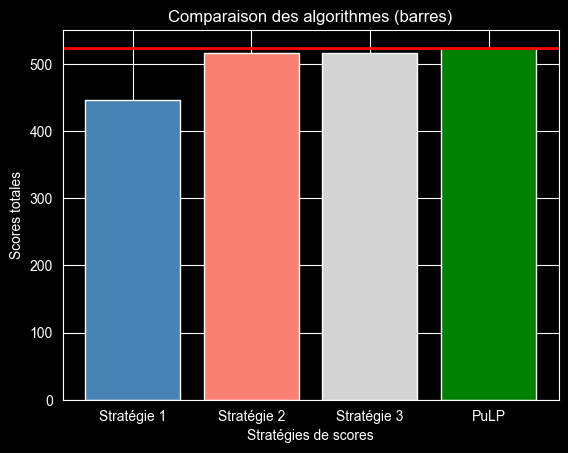

In [138]:
import  matplotlib.pyplot as plt #Import de la librairie graphique

# La iiste des différentes approches de scores obtenu dans le numéro 1 et 2
dict_approches = {
    "Stratégie 1" : 446,
    "Stratégie 2" : 516,
    "Stratégie 3" : 516,
    "PuLP" : 524
}

# liste de couleurs pour distinguer les barres
color = ['steelblue', 'salmon','lightgray','green']
#indice pour la liste de couleur
i = 0
#titre du graphqiue
plt.title("Comparaison des algorithmes (barres)")
#titre pour l'axe des x
plt.xlabel("Stratégies de scores")

#titre pour l'axe des y
plt.ylabel("Scores totales")

#iteration sur pour tracer les barres et mettre une couleur
for key, value in dict_approches.items():
    plt.bar(x=key,height=value,color=color[i])
    i+=1

#ajout de la ligne horizontale de référence au score optimale
plt.axhline(y=dict_approches['PuLP'], color='red',linewidth=2)

# afficher le graphique
plt.show()

### Croissance du nombre d’appels récursifs

[{'nom': 'David', 'score': 93, 'salaire': 2100, 'poids': 90}, {'nom': 'Bob', 'score': 91, 'salaire': 1800, 'poids': 85}, {'nom': 'Hugo', 'score': 89, 'salaire': 1600, 'poids': 80}, {'nom': 'Alice', 'score': 88, 'salaire': 1200, 'poids': 72}, {'nom': 'Clara', 'score': 84, 'salaire': 950, 'poids': 68}, {'nom': 'Emma', 'score': 79, 'salaire': 800, 'poids': 65}]
fib_naif(35) = 11139499 Temps :  0.056 s
fib_memo(35) = 11139499 Temps :  0.000248 s
242785 49


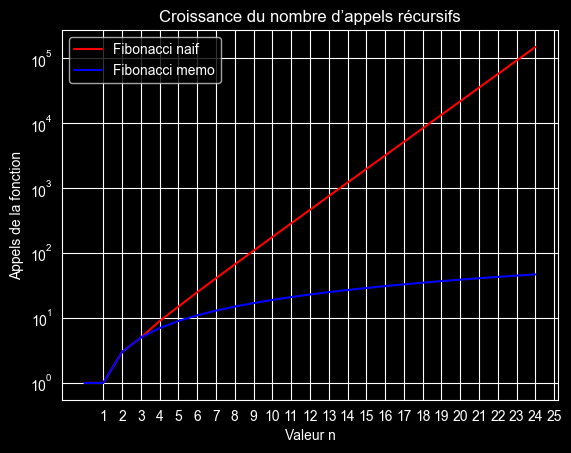

In [139]:
import time
import matplotlib.pyplot as plt
import numpy as np

#competurs
compteurs = {
    "compteur_naif" : 0,
    "compteur_memo" : 0
}
# fonction naive
def fib_naif(joueurs,n,cpt):
    if n == 0:
        cpt['compteur_naif'] +=1
        return joueurs[0]['score']
    if n == 1:
        cpt['compteur_naif'] +=1
        return joueurs[1]['score']
    cpt['compteur_naif'] +=1
    return fib_naif(joueurs,n-1,cpt) + fib_naif(joueurs,n-2,cpt)

#fonction de mémoisé
def fib_memo(joueurs,n,cpt,memo=None,):
    if memo is None:
        memo = {}
    if n == 0:
        cpt['compteur_memo'] +=1
        return joueurs[0]['score']
    if n == 1:
        cpt['compteur_memo'] +=1
        return joueurs[1]['score']
    if n in memo:
        cpt['compteur_memo'] +=1
        return memo[n]
    cpt['compteur_memo'] +=1
    memo[n] = fib_memo(joueurs,n - 1,cpt, memo) + fib_memo(joueurs,n - 2,cpt, memo)
    return memo[n]



# liste de joueurs dans l'équipe A et B
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80},
]

# Triés les joueurs du plus de scores au moins
joueurs_tries = sorted(joueurs,key=lambda j: j["score"],reverse=True)
print(joueurs_tries)


#comparaison de te,s pour les 2 méthodes

debut = time.perf_counter()
compteurs['compteur_naif'] = 0
resultat = fib_naif(joueurs_tries,25,compteurs)
fin = time.perf_counter()
print(f"fib_naif(35) = { resultat} Temps : { fin - debut: .3f} s")

debut = time.perf_counter()
compteurs['compteur_memo'] = 0
resultat = fib_memo(joueurs_tries,25,compteurs)
fin = time.perf_counter()
print(f"fib_memo(35) = { resultat} Temps : { fin - debut: .6f} s")
print(compteurs['compteur_naif'],compteurs['compteur_memo'])

####################GRAPHIQUE#########################################
# Axe des X va de 1 a 25
plt.xticks(range(1,26))

#Axe des Y de 1 a 10000 log permets pas le 0 ou les negatifs
plt.yticks([10, 100, 1000, 10000])
plt.yscale('log')

#liste vide pour stocker les resultats
liste_n = []
liste_fib_naif = []
liste_fib_memo = []

# boucle pour stocker les resultats
for i in range(25):
    compteurs['compteur_naif'] = 0
    compteurs['compteur_memo'] = 0
    resultats = fib_naif(joueurs_tries,i,compteurs)
    resultat_memo = fib_memo(joueurs_tries,i,compteurs)
    liste_n.append(i)
    liste_fib_naif.append(compteurs['compteur_naif'])
    liste_fib_memo.append(compteurs['compteur_memo'])

# tracer les 2 droites pour naif et memo
plt.plot(liste_n,liste_fib_naif,color="red",label="Fibonacci naif")
plt.plot(liste_n,liste_fib_memo,color="blue",label="Fibonacci memo")

# ca dit quelle ligne est laquelle en haut a gauche
plt.legend(loc="upper left")

#titre du graphqiue
plt.title("Croissance du nombre d’appels récursifs")

#titre pour l'axe des x
plt.xlabel("Valeur n")

#titre pour l'axe des y
plt.ylabel("Appels de la fonction")

# afficher le graphique
plt.show()


### Répartition du budget et du poids par équipe

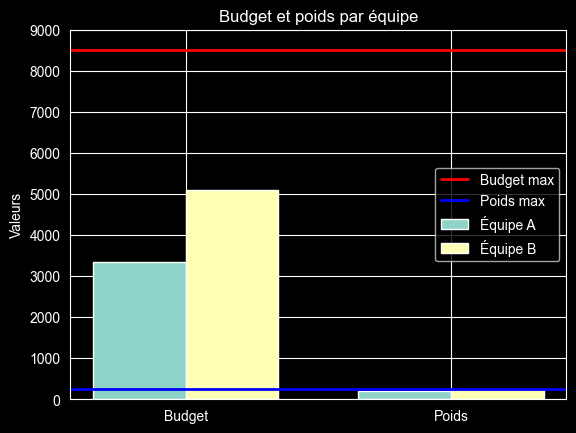

In [144]:
import  matplotlib.pyplot as plt #Import de la librairie graphique
import numpy as np

#contraintes
BUDGET_MAX  = 8500
POIDS_MAX = 250
# La iiste des budgets et poids des deux equipes
categories = ["Budget", "Poids"]
equipe_A = [3350,213.0]
equipe_B = [5100.0,247.0]


x = np.arange(len(categories))
width = 0.35

#les barres
plt.bar(x - width/2, equipe_A, width, label="Équipe A")
plt.bar(x + width/2, equipe_B, width, label="Équipe B")

#affiche du budget et poids sur l'axe des x et la valeur sur y
plt.xticks(x, categories)
plt.ylabel("Valeurs")
plt.title("Budget et poids par équipe")

#ajout de la ligne horizontale de référence au score optimale
plt.axhline(y=BUDGET_MAX, color='red',linewidth=2,label="Budget max")
plt.axhline(y=POIDS_MAX, color='blue',linewidth=2,label="Poids max")

#affiche
plt.legend()

#bond de 1000 sur y
plt.ylim(0,9000)

# afficher le graphique
plt.show()

